<a href="https://colab.research.google.com/github/khancaffeine/MNIST-Multi-Digit-Regression/blob/main/notebooks/EDA_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install kaggle

Mounted at /content/drive


In [5]:
from getpass import getpass
import os

os.environ["KAGGLE_API_TOKEN"] = getpass("Enter Kaggle Token: ")

!kaggle datasets list -s mnist

KeyboardInterrupt: Interrupted by user

In [ ]:
!mkdir data

!kaggle datasets download \
-d youssef019/mnist-multi-digit-regression-dataset \
-p data \
--unzip

-------Imports---------


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

import os
import random

Dataset Overview

In [ ]:
df = pd.read_csv('/content/data/labels.csv')

print(df.shape)
print(df.head())
print(df.isnull().sum())
print(df.duplicated().sum())

(60000, 2)
   image     label
0  0.png   6290448
1  1.png    101651
2  2.png  36731246
3  3.png  24680373
4  4.png   8868017
image    0
label    0
dtype: int64
0


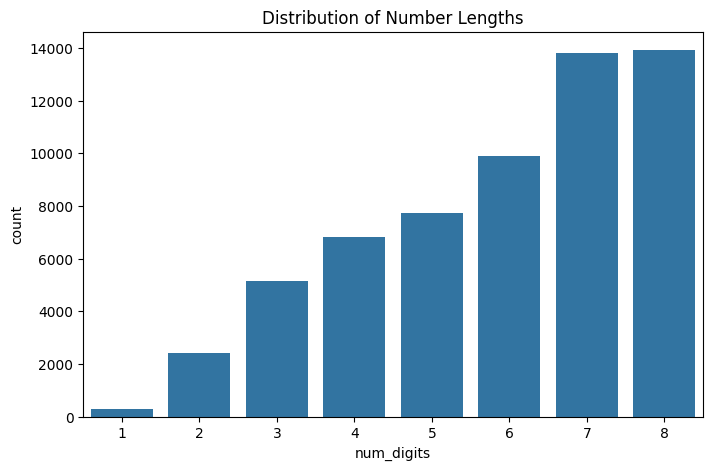

In [ ]:
df["label_str"] = df["label"].astype(str)

df["num_digits"] = df["label_str"].str.len()

plt.figure(figsize=(8,5))

sns.countplot(
    x=df["num_digits"],
    order=sorted(df["num_digits"].unique())
)

plt.title("Distribution of Number Lengths")
plt.show()

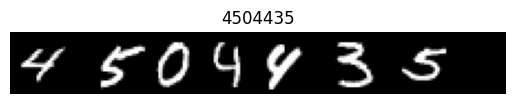

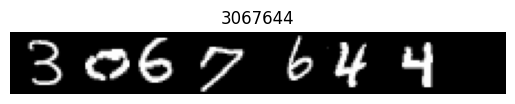

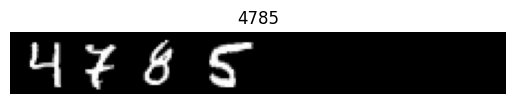

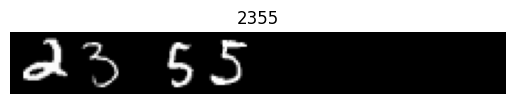

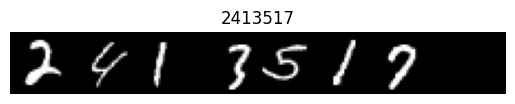

In [ ]:
sample = df.sample(5)

for i in range(len(sample)):

    img = Image.open(
        f"/content/data/images/{sample.iloc[i]['image']}"
    )

    plt.imshow(img, cmap='gray')
    plt.title(sample.iloc[i]['label'])
    plt.axis('off')
    plt.show()

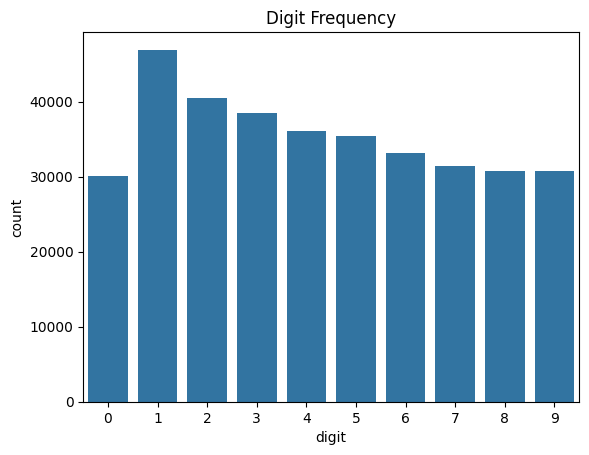

In [ ]:
all_digits = ''.join(df['label_str'])
digit_counts = Counter(all_digits)
digit_counts
digit_df = pd.DataFrame(
    digit_counts.items(),
    columns=['digit','count']
)

digit_df = digit_df.sort_values('digit')

sns.barplot(
    data=digit_df,
    x='digit',
    y='count'
)

plt.title("Digit Frequency")
plt.show()

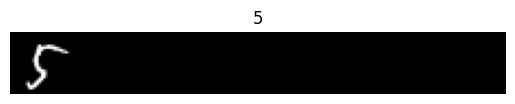

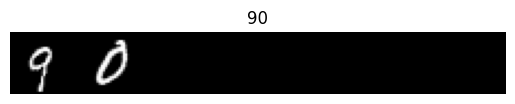

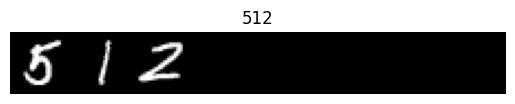

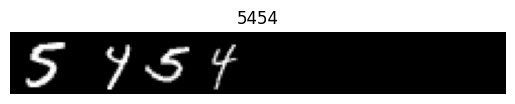

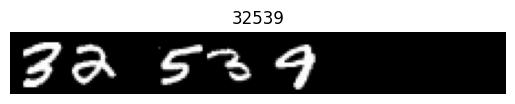

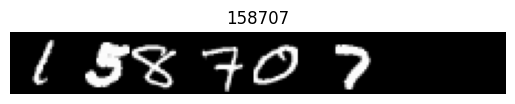

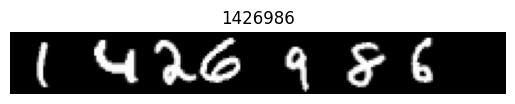

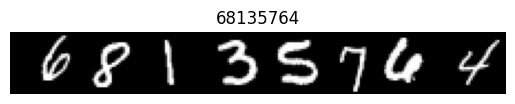

In [ ]:
df['length'] = df['label'].astype(str).str.len()
for length in range(1, 9):
    sample = df[df['length'] == length].sample(1)

    img = Image.open(
        f"/content/data/images/{sample.iloc[0]['image']}"
    )

    plt.imshow(img, cmap='gray')
    plt.title(sample.iloc[0]['label'])
    plt.axis('off')
    plt.show()

# Key Findings

1. The dataset contains 60,000 image-label pairs with no missing values.

2. Each image is a grayscale image of size 224 × 28 pixels.

3. Labels represent digit sequences ranging from 1 to 8 digits in length.

4. Most samples contain 6–8 digits, indicating that the dataset is dominated by longer sequences.

5. Images are formed by horizontally concatenating MNIST digits with slight random positional shifts.

6. The dataset exhibits moderate variation in digit frequencies. Although all classes contain a large number of samples and no class is severely underrepresented, digit 1 is the most common while digits 0, 8, and 9 occur less frequently.

7. Since the maximum sequence length is 8, a fixed-length output baseline model(Multi-head CNN) is feasible.

8. More advanced sequence models such as CNN-BiLSTM and CNN-BiLSTM-CTC can also be explored.
